# Financial Health Score Generator

This notebook builds an end-to-end machine learning pipeline that scores a person's financial health (0-100) from their income, spending, savings, debt and credit data, and then gives personalized financial recommendations.

**Flow of this notebook:**
1. Setup & Data Loading
2. Data Inspection & Cleaning
3. Feature Engineering (financial ratios + target score)
4. Exploratory Data Analysis (EDA)
5. Encoding & Train/Test Preparation
6. Model Training & Comparison
7. Best Model Selection & Feature Selection (RFE)
8. Retraining on Selected Features
9. Recommendation Engine
10. Conclusion & Saving Artifacts for Deployment

## 1. Setup & Data Loading

Import all the libraries needed for data handling, visualization, preprocessing and modeling, then load the raw dataset.

**Import Libraries**

Loads pandas/numpy for data handling, matplotlib/seaborn for plots, scikit-learn for preprocessing and ML models, TensorFlow/Keras for the neural network, and statsmodels for multicollinearity checks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Install statsmodels**

Ensures the `statsmodels` package (used later for Variance Inflation Factor) is available in the environment.

In [ ]:
pip install statsmodels

**Load Dataset**

Reads the raw `personal_finance_dataset.csv` file into a pandas DataFrame.

In [2]:
df=pd.read_csv("personal_finance_dataset.csv")
df

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,353.67,1504.56,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,594.08,1450.72,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,556.86,1000.00,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2023-07-09,1822,3254.55,3992.02,0.17,2675.77,normal,704.0,0.30,285.16,...,408.23,2088.32,Mixed,2079.99,Healthcare,Positive,43.2,Low,0.00,0
2996,2023-08-08,1907,2752.78,5685.18,0.26,2682.99,recession,697.0,0.12,417.06,...,167.78,2445.34,Salary,832.95,Entertainment,Neutral,46.0,Low,0.00,0
2997,2023-09-07,1464,3691.10,3228.05,0.12,3893.53,normal,626.0,0.12,621.01,...,275.53,3231.56,Salary,790.68,Utilities,Neutral,40.7,Medium,463.05,0
2998,2023-10-07,1346,3133.24,4335.72,0.08,2854.72,inflation,628.0,0.42,650.23,...,373.85,2305.14,Salary,903.82,Utilities,Positive,57.1,Low,0.00,0


## 2. Data Inspection & Cleaning

Get a quick feel for the data's shape, types and quality before doing any feature work.

**Dataset Shape**

Checks the number of rows and columns in the dataset.

In [3]:
df.shape

(3000, 25)

**Dataset Info**

Shows column names, data types and non-null counts.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   user_id                 3000 non-null   int64  
 2   monthly_income          3000 non-null   float64
 3   monthly_expense_total   3000 non-null   float64
 4   savings_rate            3000 non-null   float64
 5   budget_goal             3000 non-null   float64
 6   financial_scenario      3000 non-null   object 
 7   credit_score            3000 non-null   float64
 8   debt_to_income_ratio    3000 non-null   float64
 9   loan_payment            3000 non-null   float64
 10  investment_amount       3000 non-null   float64
 11  subscription_services   3000 non-null   int64  
 12  emergency_fund          3000 non-null   float64
 13  transaction_count       3000 non-null   int64  
 14  fraud_flag              3000 non-null   

**Summary Statistics (All Columns)**

Displays basic descriptive statistics for every column.

In [5]:
df.describe()

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,fraud_flag,discretionary_spending,essential_spending,rent_or_mortgage,financial_advice_score,actual_savings,savings_goal_met
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1498.699000,4004.267347,3011.682230,0.225897,2811.070463,679.923667,0.350817,508.58113,400.610493,4.975000,1005.349830,59.529333,0.023667,500.810990,2215.587100,1211.897797,50.071133,1156.418457,0.092333
std,287.352782,1000.107096,801.151864,0.101417,490.855344,49.970847,0.145191,199.44458,235.361273,2.559536,485.780881,23.101610,0.152034,199.800377,596.267983,400.482024,29.087360,1039.597384,0.289544
min,1000.000000,685.280000,159.210000,0.050000,1175.570000,515.000000,0.100000,0.00000,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,1000.000000,300.000000,0.100000,0.000000,0.000000
25%,1248.750000,3362.250000,2473.205000,0.140000,2481.957500,646.000000,0.220000,375.34000,234.780000,3.000000,674.012500,38.750000,0.000000,361.562500,1807.235000,933.530000,25.100000,144.965000,0.000000
50%,1496.500000,4008.075000,3023.810000,0.230000,2822.285000,679.000000,0.350000,508.57000,388.075000,5.000000,1010.485000,60.000000,0.000000,496.340000,2215.705000,1213.605000,48.700000,1032.810000,0.000000
75%,1749.000000,4659.040000,3555.502500,0.310000,3131.000000,713.000000,0.480000,638.47000,559.842500,7.000000,1337.820000,79.000000,0.000000,640.105000,2624.675000,1482.860000,76.100000,1821.510000,0.000000
max,1999.000000,7407.940000,5853.200000,0.400000,4386.500000,847.000000,0.600000,1176.88000,1292.300000,9.000000,2585.360000,99.000000,1.000000,1158.740000,4245.900000,2614.620000,100.000000,6589.660000,1.000000


**Summary Statistics (Numeric Columns)**

Same as above, restricted to numeric columns for a cleaner view.

In [6]:
df.describe(include='number')

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,fraud_flag,discretionary_spending,essential_spending,rent_or_mortgage,financial_advice_score,actual_savings,savings_goal_met
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1498.699000,4004.267347,3011.682230,0.225897,2811.070463,679.923667,0.350817,508.58113,400.610493,4.975000,1005.349830,59.529333,0.023667,500.810990,2215.587100,1211.897797,50.071133,1156.418457,0.092333
std,287.352782,1000.107096,801.151864,0.101417,490.855344,49.970847,0.145191,199.44458,235.361273,2.559536,485.780881,23.101610,0.152034,199.800377,596.267983,400.482024,29.087360,1039.597384,0.289544
min,1000.000000,685.280000,159.210000,0.050000,1175.570000,515.000000,0.100000,0.00000,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,1000.000000,300.000000,0.100000,0.000000,0.000000
25%,1248.750000,3362.250000,2473.205000,0.140000,2481.957500,646.000000,0.220000,375.34000,234.780000,3.000000,674.012500,38.750000,0.000000,361.562500,1807.235000,933.530000,25.100000,144.965000,0.000000
50%,1496.500000,4008.075000,3023.810000,0.230000,2822.285000,679.000000,0.350000,508.57000,388.075000,5.000000,1010.485000,60.000000,0.000000,496.340000,2215.705000,1213.605000,48.700000,1032.810000,0.000000
75%,1749.000000,4659.040000,3555.502500,0.310000,3131.000000,713.000000,0.480000,638.47000,559.842500,7.000000,1337.820000,79.000000,0.000000,640.105000,2624.675000,1482.860000,76.100000,1821.510000,0.000000
max,1999.000000,7407.940000,5853.200000,0.400000,4386.500000,847.000000,0.600000,1176.88000,1292.300000,9.000000,2585.360000,99.000000,1.000000,1158.740000,4245.900000,2614.620000,100.000000,6589.660000,1.000000


## Data Preprocessing

Check for missing values and duplicate rows so the dataset is clean before feature engineering.

**Check Missing Values**

Counts null values per column to spot data quality issues.

In [7]:
df.isnull().sum()

date                      0
user_id                   0
monthly_income            0
monthly_expense_total     0
savings_rate              0
budget_goal               0
financial_scenario        0
credit_score              0
debt_to_income_ratio      0
loan_payment              0
investment_amount         0
subscription_services     0
emergency_fund            0
transaction_count         0
fraud_flag                0
discretionary_spending    0
essential_spending        0
income_type               0
rent_or_mortgage          0
category                  0
cash_flow_status          0
financial_advice_score    0
financial_stress_level    0
actual_savings            0
savings_goal_met          0
dtype: int64

**Check Duplicate Rows**

Counts fully duplicated rows in the dataset.

In [8]:
duplicate=df.duplicated().sum()
print(duplicate)


0


**Convert Date Column**

Converts the `date` column from text to a proper `datetime` type so it can be used in time-based analysis.

In [9]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    3000 non-null   datetime64[ns]
 1   user_id                 3000 non-null   int64         
 2   monthly_income          3000 non-null   float64       
 3   monthly_expense_total   3000 non-null   float64       
 4   savings_rate            3000 non-null   float64       
 5   budget_goal             3000 non-null   float64       
 6   financial_scenario      3000 non-null   object        
 7   credit_score            3000 non-null   float64       
 8   debt_to_income_ratio    3000 non-null   float64       
 9   loan_payment            3000 non-null   float64       
 10  investment_amount       3000 non-null   float64       
 11  subscription_services   3000 non-null   int64         
 12  emergency_fund          3000 non-null   float64 

## 3. Financial Terminology & Feature Engineering

Derive new financial ratio features from the raw columns. These ratios capture financial behaviour (spending, saving, investing, debt) far better than the raw currency amounts.

**Expense Ratio**

How much of monthly income is spent: `monthly_expense_total / monthly_income`.

In [10]:
df['expense_ratio'] = (
    df['monthly_expense_total'] / df['monthly_income']
)
df['expense_ratio']


0       1.029648
1       1.144177
2       1.137957
3       0.663738
4       0.473766
          ...   
2995    1.226597
2996    2.065250
2997    0.874550
2998    1.383782
2999    0.867183
Name: expense_ratio, Length: 3000, dtype: float64

**Savings Ratio**

How much of monthly income is actually saved: `actual_savings / monthly_income`.

In [11]:
df['saving ratio']=(
    df['actual_savings']/df['monthly_income']
)
df['saving ratio']

0       0.000000
1       0.000000
2       0.000000
3       0.336262
4       0.526234
          ...   
2995    0.000000
2996    0.000000
2997    0.125450
2998    0.000000
2999    0.132817
Name: saving ratio, Length: 3000, dtype: float64

**Investment Ratio**

Share of income going into investments: `investment_amount / monthly_income`.

In [12]:
df['investment Ratio']=(
   df['investment_amount']/df['monthly_income']
)
df['investment Ratio']

0       0.220934
1       0.110451
2       0.000000
3       0.051916
4       0.074406
          ...   
2995    0.183663
2996    0.213399
2997    0.077611
2998    0.308499
2999    0.000000
Name: investment Ratio, Length: 3000, dtype: float64

**Debt Burden**

Share of expenses used for loan repayment: `loan_payment / monthly_expense_total`.

In [13]:
df['debt burden']=(
    df['loan_payment']/df['monthly_expense_total']
)
df['debt burden']

0       0.039155
1       0.121675
2       0.291350
3       0.207408
4       0.120839
          ...   
2995    0.071433
2996    0.073359
2997    0.192379
2998    0.149970
2999    0.033029
Name: debt burden, Length: 3000, dtype: float64

**Spending Gap**

Absolute leftover money each month: `monthly_income - monthly_expense_total`.

In [14]:
df['spending_gap'] = (
    df['monthly_income']
    - df['monthly_expense_total']
    )
df['spending_gap']


0        -92.49
1       -470.37
2       -404.38
3       1179.20
4       2424.29
         ...   
2995    -737.47
2996   -2932.40
2997     463.05
2998   -1202.48
2999     543.23
Name: spending_gap, Length: 3000, dtype: float64

**Emergency Fund Coverage**

How many months of expenses the emergency fund can cover: `emergency_fund / monthly_expense_total`.

In [15]:
df['emergency_fund_coverage'] = (
    df['emergency_fund'] / df['monthly_expense_total']
)
df['emergency_fund_coverage']


0       0.158957
1       0.309260
2       0.429616
3       0.097685
4       0.270235
          ...   
2995    0.116760
2996    0.142099
2997    0.241685
2998    0.164245
2999    0.254506
Name: emergency_fund_coverage, Length: 3000, dtype: float64

**Clean Up Ratio Columns**

Replaces infinite values (from divide-by-zero) with NaN, clips extreme outliers at the 99th percentile, and fills remaining NaNs with 0 so the ratio features are safe to model on.

In [16]:
ratio_cols = ['expense_ratio', 'saving ratio', 'investment Ratio', 'debt burden', 'emergency_fund_coverage']
for c in ratio_cols:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].clip(upper=df[c].quantile(0.99))
    df[c] = df[c].fillna(0)

df[ratio_cols].describe()

,expense_ratio,saving ratio,investment Ratio,debt burden,emergency_fund_coverage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.807860,0.256319,0.107630,0.183381,0.362285
std,0.333012,0.206866,0.072830,0.095933,0.216189
min,0.034643,0.000000,0.000000,0.000000,0.000000
25%,0.583216,0.043199,0.057233,0.119743,0.217526
50%,0.749035,0.250965,0.097832,0.167212,0.334715
75%,0.956801,0.416784,0.145516,0.227401,0.471112
max,2.099725,0.745420,0.354152,0.551118,1.142228


**Correlation Check vs. Original Target**

Checks how strongly each numeric feature correlates with the original `financial_advice_score` column, to see whether it's a usable target.

In [17]:
num_cols = df.select_dtypes(include='number').columns
print(df[num_cols].corr()['financial_advice_score'].sort_values(ascending=False))

financial_advice_score     1.000000
fraud_flag                 0.017286
transaction_count          0.015967
monthly_income             0.015544
savings_rate               0.010440
spending_gap               0.009352
essential_spending         0.008257
saving ratio               0.006917
rent_or_mortgage           0.006484
actual_savings             0.005030
monthly_expense_total      0.004440
credit_score               0.001759
budget_goal                0.000804
emergency_fund            -0.004609
user_id                   -0.006058
emergency_fund_coverage   -0.006390
investment_amount         -0.009452
debt burden               -0.011401
subscription_services     -0.012374
loan_payment              -0.012444
expense_ratio             -0.013571
debt_to_income_ratio      -0.017492
savings_goal_met          -0.020426
investment Ratio          -0.021953
discretionary_spending    -0.025591
Name: financial_advice_score, dtype: float64


## 4. Exploratory Data Analysis (EDA)

Visualize distributions and relationships to understand the data before modeling.

**Income Distribution**

Histogram of `monthly_income` across all users.

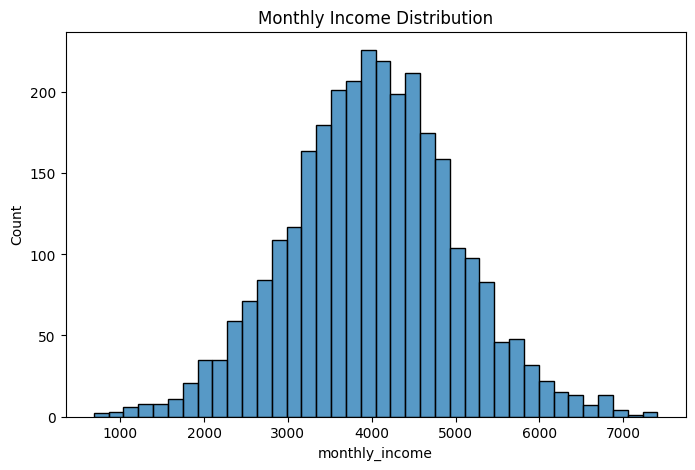

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['monthly_income'])
plt.title("Monthly Income Distribution")
plt.show()

**Expense Distribution**

Histogram (with density curve) of `monthly_expense_total`.

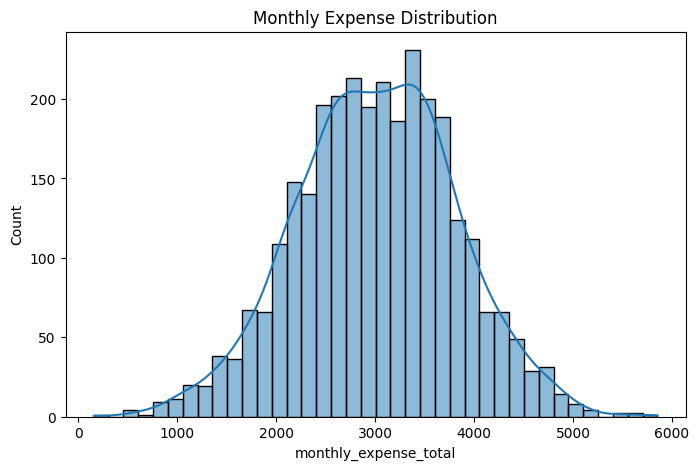

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['monthly_expense_total'],kde=True)
plt.title("Monthly Expense Distribution")
plt.show()

**Savings Distribution**

Histogram of `actual_savings`.

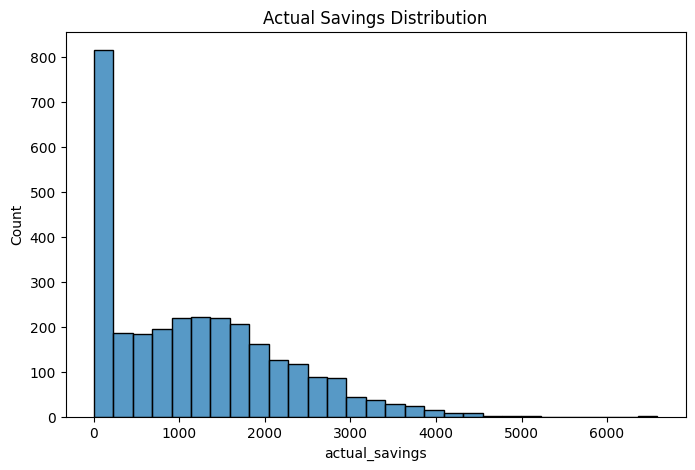

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['actual_savings'])
plt.title("Actual Savings Distribution")
plt.show()

**Build & Visualize the Financial Health Score**

This is the core of the project: a custom `financial_health_score` (0-100) is built as a weighted blend of normalized credit score, savings rate, debt-to-income, emergency fund coverage, discretionary spending, investment ratio, loan burden, cash-flow status, stress level and savings-goal-met — minus a penalty for flagged fraud. The result becomes the target variable the models will predict, and its distribution is plotted.

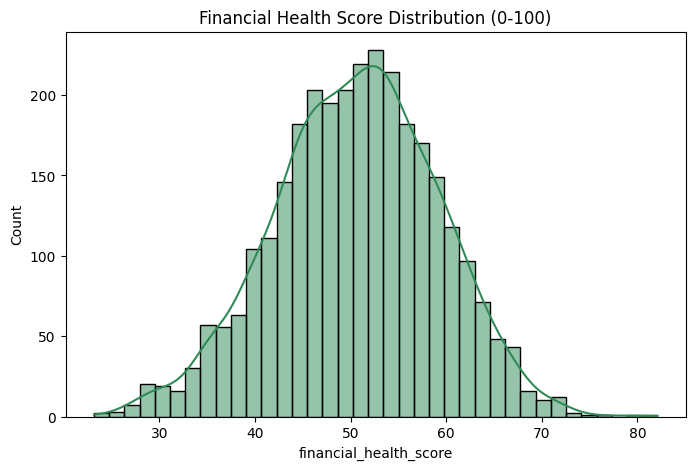

In [21]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

credit_n   = minmax(df['credit_score'])
savings_n  = minmax(df['savings_rate'])
dti_n      = 1 - minmax(df['debt_to_income_ratio'])
ef_n       = minmax(df['emergency_fund_coverage'])
disc_n     = 1 - minmax(df['discretionary_spending'] / df['monthly_income'])
invest_n   = minmax(df['investment Ratio'])
loan_n     = 1 - minmax(df['debt burden'])
# Corrected mappings using string labels
cashflow_n = df['cash_flow_status'].map({'Positive': 1.0, 'Neutral': 0.5, 'Negative': 0.0})
stress_n   = df['financial_stress_level'].map({'Low': 1.0, 'Medium': 0.5, 'High': 0.0})
goal_n     = df['savings_goal_met'].astype(float)
fraud      = df['fraud_flag'].astype(float)

WEIGHTS = {
    'credit': 0.18, 'savings': 0.16, 'dti': 0.14, 'ef': 0.14, 'disc': 0.08,
    'invest': 0.06, 'loan': 0.06, 'cash': 0.08, 'stress': 0.06, 'goal': 0.04,
}

score = (
    WEIGHTS['credit'] * credit_n + WEIGHTS['savings'] * savings_n + WEIGHTS['dti'] * dti_n +
    WEIGHTS['ef'] * ef_n + WEIGHTS['disc'] * disc_n + WEIGHTS['invest'] * invest_n +
    WEIGHTS['loan'] * loan_n + WEIGHTS['cash'] * cashflow_n + WEIGHTS['stress'] * stress_n +
    WEIGHTS['goal'] * goal_n
) * 100

score = (score - 10 * fraud).clip(0, 100)
df['financial_health_score'] = score.round(2)

plt.figure(figsize=(8,5))
sns.histplot(df['financial_health_score'], kde=True, color='seagreen')
plt.title("Financial Health Score Distribution (0-100)")
plt.show()

**Credit Score Boxplot**

Boxplot to inspect the spread and outliers of `credit_score`.

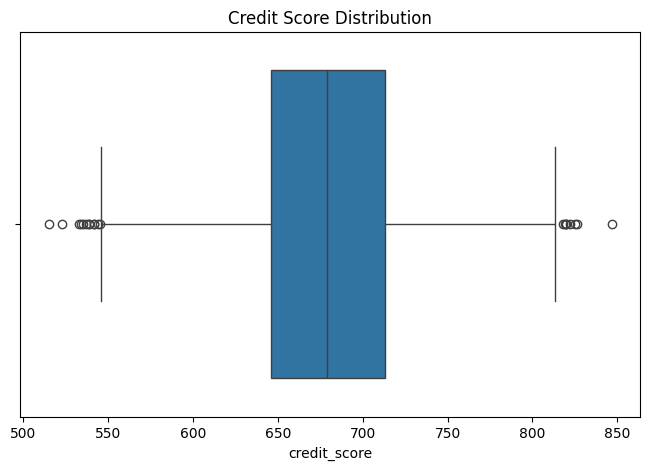

In [22]:
if 'credit_score' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='credit_score', data=df)
    plt.title("Credit Score Distribution")
    plt.show()


## Categorical Variable Distributions

Count plots showing how many records fall into each category for the key categorical columns.

**Financial Scenario Distribution**

Count plot of the `financial_scenario` categories.

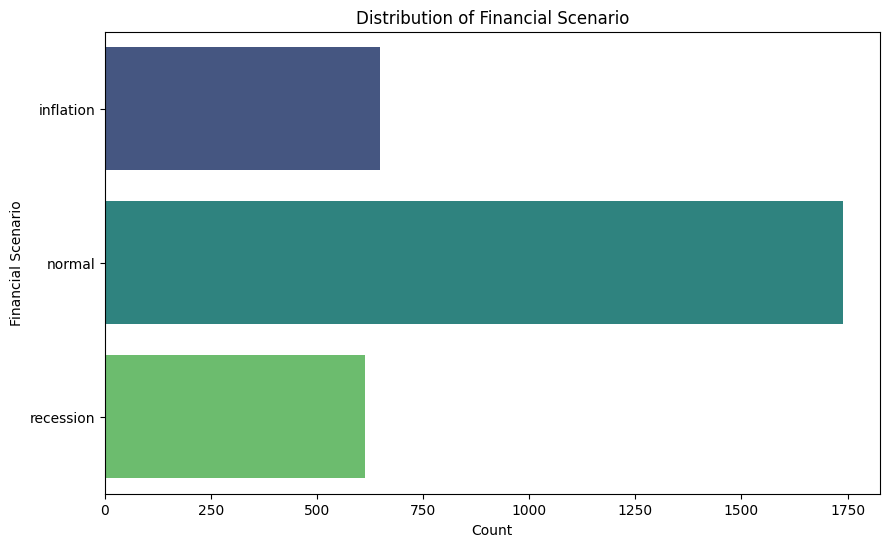

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(y='financial_scenario', data=df, palette='viridis', hue='financial_scenario', legend=False)
plt.title('Distribution of Financial Scenario')
plt.xlabel('Count')
plt.ylabel('Financial Scenario')
plt.show()

**Income Type Distribution**

Count plot of the `income_type` categories.

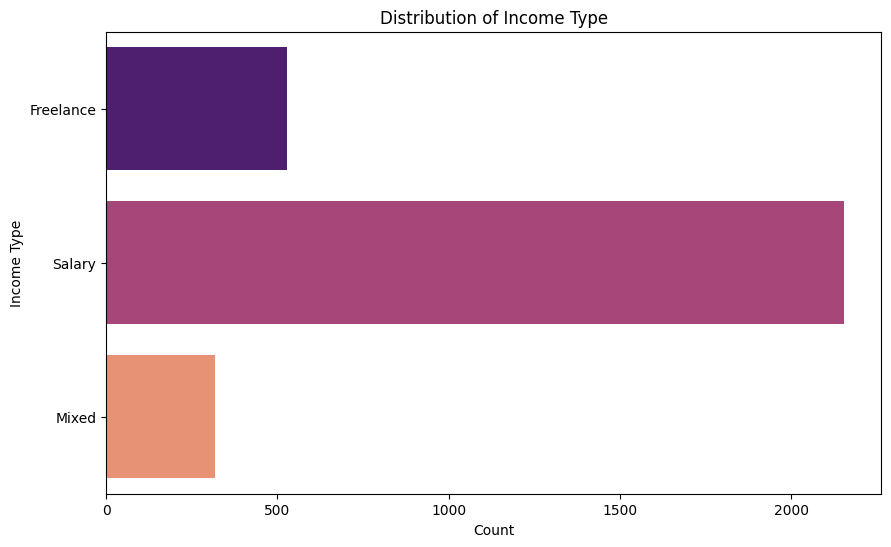

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(y='income_type', data=df, palette='magma', hue='income_type', legend=False)
plt.title('Distribution of Income Type')
plt.xlabel('Count')
plt.ylabel('Income Type')
plt.show()

**Category Distribution**

Count plot of the `category` column.

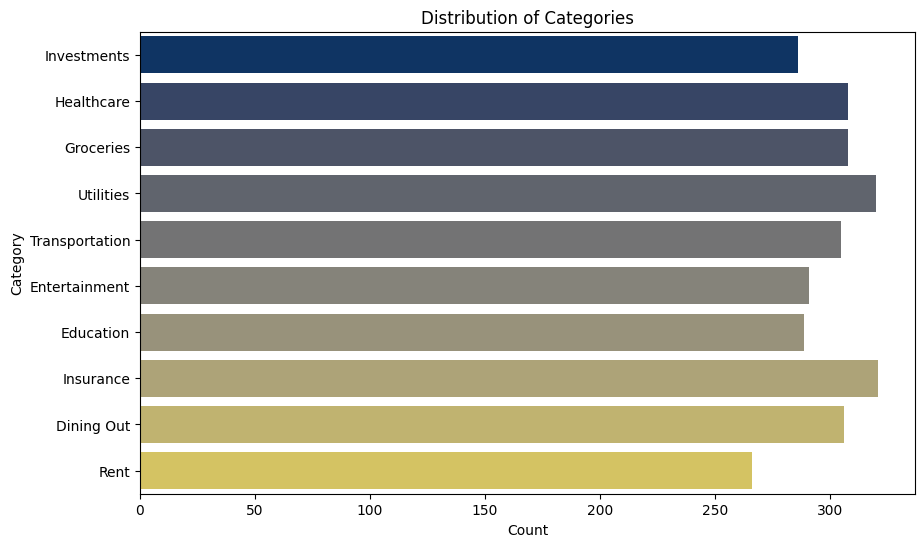

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, palette='cividis', hue='category', legend=False)
plt.title('Distribution of Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

**Cash Flow Status Distribution**

Count plot of the `cash_flow_status` categories.

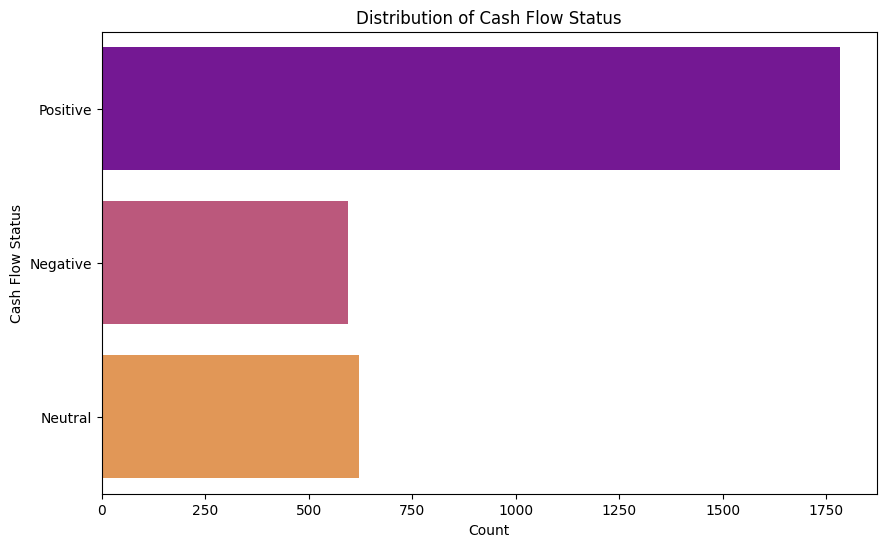

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(y='cash_flow_status', data=df, palette='plasma', hue='cash_flow_status', legend=False)
plt.title('Distribution of Cash Flow Status')
plt.xlabel('Count')
plt.ylabel('Cash Flow Status')
plt.show()

**Financial Stress Level Distribution**

Count plot of the `financial_stress_level` categories.

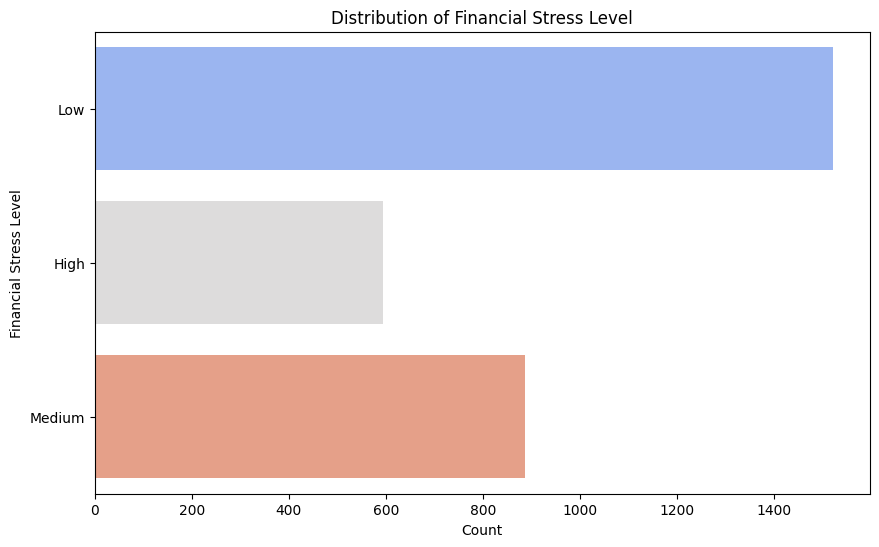

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(y='financial_stress_level', data=df, palette='coolwarm', hue='financial_stress_level', legend=False)
plt.title('Distribution of Financial Stress Level')
plt.xlabel('Count')
plt.ylabel('Financial Stress Level')
plt.show()

**Correlation Heatmap**

Heatmap of correlations between all numeric features, used to spot redundant or highly related variables.

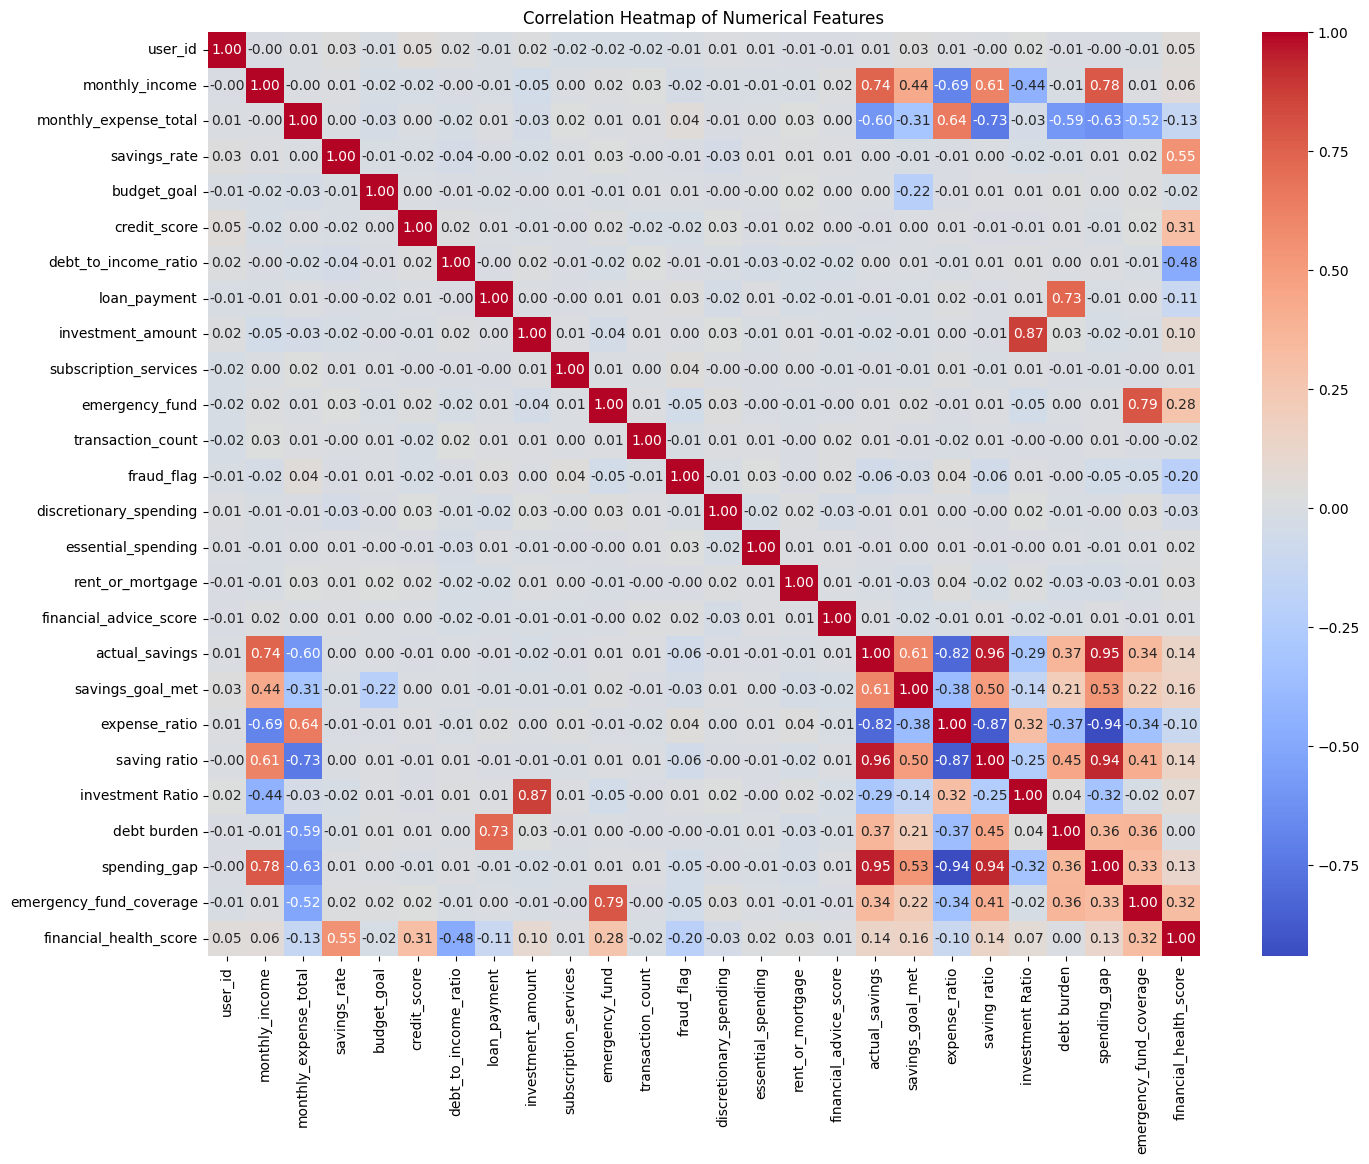

In [28]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Target Variable Distribution**

Histogram (with density curve) of the `financial_health_score` target, to see its overall shape before modeling.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['financial_health_score'], kde=True, color='seagreen')
plt.title("Financial Health Score Distribution")
plt.xlabel("Financial Health Score")
plt.show()

**Engineered Ratio Features — Distributions**

Grid of histograms for the five engineered ratio features (`expense_ratio`, `saving ratio`, `investment Ratio`, `debt burden`, `emergency_fund_coverage`) to check their spread after cleaning.

In [ ]:
ratio_cols = ['expense_ratio', 'saving ratio', 'investment Ratio', 'debt burden', 'emergency_fund_coverage']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(ratio_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkorange')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribution of Engineered Ratio Features')
plt.tight_layout()
plt.show()

**Outlier Check — Key Numeric Columns**

Side-by-side boxplots of the core raw numeric columns to visually flag outliers before they feed into modeling.

In [ ]:
numeric_check_cols = ['monthly_income', 'monthly_expense_total', 'actual_savings', 'loan_payment']

fig, axes = plt.subplots(1, len(numeric_check_cols), figsize=(16, 5))
for i, col in enumerate(numeric_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='cornflowerblue')
    axes[i].set_title(col)
plt.suptitle('Outlier Check for Key Numeric Columns')
plt.tight_layout()
plt.show()

**Income vs. Savings by Cash Flow Status**

Scatter plot of `monthly_income` against `actual_savings`, colored by `cash_flow_status`, to see how saving behaviour varies with cash flow health.

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='monthly_income', y='actual_savings',
    hue='cash_flow_status', palette='Set2', alpha=0.7
)
plt.title('Monthly Income vs. Actual Savings by Cash Flow Status')
plt.xlabel('Monthly Income')
plt.ylabel('Actual Savings')
plt.legend(title='Cash Flow Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Financial Health Score by Financial Scenario**

Boxplot comparing the distribution of `financial_health_score` across `financial_scenario` categories, to see which scenarios tend to score higher or lower.

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='financial_health_score', y='financial_scenario',
    hue='financial_scenario', palette='Spectral', legend=False
)
plt.title('Financial Health Score by Financial Scenario')
plt.xlabel('Financial Health Score')
plt.ylabel('Financial Scenario')
plt.tight_layout()
plt.show()

**Pairwise Relationships Between Key Ratios**

Pairplot of the core ratio features colored by `cash_flow_status`, to visually spot clusters and relationships between savings, investment, debt and expense behaviour.

In [ ]:
pair_cols = ['expense_ratio', 'saving ratio', 'investment Ratio', 'debt burden']
sns.pairplot(df, vars=pair_cols, hue='cash_flow_status', palette='husl', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle('Pairwise Relationships Between Key Ratios', y=1.02)
plt.show()

## 5. Encoding & Train/Test Preparation

Encode categorical columns to numbers and set up the feature matrix `X` and target `y` for modeling.

**Preview Engineered Data**

Quick look at the DataFrame after feature engineering, before encoding.

In [29]:
df.head()

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,financial_stress_level,actual_savings,savings_goal_met,expense_ratio,saving ratio,investment Ratio,debt burden,spending_gap,emergency_fund_coverage,financial_health_score
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,Low,0.00,0,1.029648,0.000000,0.220934,0.039155,-92.49,0.158957,57.97
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,Low,0.00,0,1.144177,0.000000,0.110451,0.121675,-470.37,0.309260,46.48
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,Low,0.00,0,1.137957,0.000000,0.000000,0.291350,-404.38,0.429616,53.12
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,Low,1179.20,0,0.663738,0.336262,0.051916,0.207408,1179.20,0.097685,54.93
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,High,2424.29,0,0.473766,0.526234,0.074406,0.120839,2424.29,0.270235,54.32


**Label Encode Categorical Columns**

Converts text categories (`financial_scenario`, `income_type`, `category`, `cash_flow_status`, `financial_stress_level`) into numeric codes so models can use them; the fitted encoders are kept for later reuse.

In [30]:
encoders = {}
categorical_cols = ['financial_scenario', 'income_type', 'category', 'cash_flow_status', 'financial_stress_level']

print("Columns to encode:", categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

Columns to encode: ['financial_scenario', 'income_type', 'category', 'cash_flow_status', 'financial_stress_level']


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,financial_stress_level,actual_savings,savings_goal_met,expense_ratio,saving ratio,investment Ratio,debt burden,spending_gap,emergency_fund_coverage,financial_health_score
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,...,1,0.00,0,1.029648,0.000000,0.220934,0.039155,-92.49,0.158957,57.97
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,0,670.0,0.42,454.19,...,1,0.00,0,1.144177,0.000000,0.110451,0.121675,-470.37,0.309260,46.48
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,0,691.0,0.24,971.82,...,1,0.00,0,1.137957,0.000000,0.000000,0.291350,-404.38,0.429616,53.12
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,1,717.0,0.16,482.76,...,1,1179.20,0,0.663738,0.336262,0.051916,0.207408,1179.20,0.097685,54.93
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,0,795.0,0.25,263.74,...,0,2424.29,0,0.473766,0.526234,0.074406,0.120839,2424.29,0.270235,54.32


**Define Features (X) and Target (y)**

Drops identifier and leakage-prone columns (`date`, `user_id`, `financial_advice_score`, `financial_health_score`, `monthly_income`, `monthly_expense_total`, `spending_gap`) to build the feature matrix `X`, with `financial_health_score` as target `y`.

In [31]:
cols = ['date', 'user_id', 'financial_advice_score', 'financial_health_score','monthly_income','monthly_expense_total','spending_gap']
X = df.drop(columns=cols)
y = df['financial_health_score']
X.columns.tolist()


['savings_rate',
 'budget_goal',
 'financial_scenario',
 'credit_score',
 'debt_to_income_ratio',
 'loan_payment',
 'investment_amount',
 'subscription_services',
 'emergency_fund',
 'transaction_count',
 'fraud_flag',
 'discretionary_spending',
 'essential_spending',
 'income_type',
 'rent_or_mortgage',
 'category',
 'cash_flow_status',
 'financial_stress_level',
 'actual_savings',
 'savings_goal_met',
 'expense_ratio',
 'saving ratio',
 'investment Ratio',
 'debt burden',
 'emergency_fund_coverage']

**Check Multicollinearity (VIF)**

Computes the Variance Inflation Factor for each numeric feature to detect and flag highly redundant/collinear features.

In [32]:
X_vif = X.select_dtypes(include=['int64', 'float64'])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
2,credit_score,89.429936
16,saving ratio,77.715491
13,actual_savings,56.912446
4,loan_payment,48.605765
19,emergency_fund_coverage,48.229153
18,debt burden,47.874138
7,emergency_fund,47.328106
17,investment Ratio,35.173976
5,investment_amount,34.942284
15,expense_ratio,34.929877


**Train/Test Split**

Splits the data into 70% training and 30% testing sets.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2100, 25) (900, 25) (2100,) (900,)


**Feature Scaling**

Standardizes features (zero mean, unit variance) using `StandardScaler`, fit on train and applied to both train and test.

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Machine Learning Models

Train and compare several regression models to predict the financial health score.

**Evaluation Helper Function**

Defines a reusable `evaluate()` function that computes MAE, RMSE and R2 for a model's predictions and stores them in a results list.

In [35]:

results = []

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append({"model": name, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 4)})
    print(f"{name} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")


**Linear Regression**

Trains a baseline Linear Regression model and evaluates it on the test set.

In [36]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)
evaluate("Linear Regression", y_test, y_pred1)

Linear Regression -> MAE: 2.202 | RMSE: 2.247 | R2: 0.9269


**Linear Regression — Cross-Validation**

Runs 5-fold cross-validation to sanity-check the model's stability.

In [37]:
cv1 = cross_val_score(
    model1,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv1)

Cross Validation Scores: [0.93186443 0.93314833 0.92572756 0.93274303 0.92972358]


**Ridge Regression**

Trains a Ridge (L2-regularized) regression model and evaluates it.

In [38]:
model2 = Ridge(alpha=0.01)
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)
evaluate("Ridge Regression", y_test, y_pred2)

Ridge Regression -> MAE: 2.202 | RMSE: 2.247 | R2: 0.9269


**Ridge Regression — Cross-Validation**

5-fold cross-validation for the Ridge model.

In [39]:
cv2 = cross_val_score(
    model2,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv2)

Cross Validation Scores: [0.93186447 0.9331484  0.92572752 0.93274282 0.92972402]


**Decision Tree Regressor — Hyperparameter Tuning**

Uses `GridSearchCV` to search over tree depth and split/leaf sizes for the best cross-validated R2.

In [ ]:
parameter = {
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
}

dtree = DecisionTreeRegressor(random_state=42)
grid = GridSearchCV(estimator=dtree, param_grid=parameter, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

**Decision Tree Regressor**

Trains the Decision Tree with the tuned hyperparameters and evaluates it.

In [40]:
model3 = DecisionTreeRegressor(random_state=42,max_depth=10, min_samples_leaf=8,min_samples_split=2)
model3.fit(X_train_scaled, y_train)
y_pred3 = model3.predict(X_test_scaled)
evaluate("Decision Tree", y_test, y_pred3)

Decision Tree -> MAE: 3.784 | RMSE: 4.801 | R2: 0.6663


**Decision Tree — Cross-Validation**

5-fold cross-validation for the Decision Tree model.

In [41]:
cv3 = cross_val_score(
    model3,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv3)

Cross Validation Scores: [0.62315771 0.68513328 0.64481203 0.65448773 0.67563158]


**Random Forest Regressor — Hyperparameter Tuning**

Uses `GridSearchCV` to find good depth/split/leaf settings for a Random Forest.

In [ ]:
parameter = {
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
}

dtree = RandomForestRegressor(random_state=42)
grid = GridSearchCV(estimator=dtree, param_grid=parameter, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

**Random Forest Regressor**

Trains the Random Forest with chosen hyperparameters and evaluates it.

In [42]:
model4 = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
model4.fit(X_train_scaled, y_train)
y_pred4 = model4.predict(X_test_scaled)
evaluate("Random Forest Regressor", y_test, y_pred4)

Random Forest Regressor -> MAE: 2.700 | RMSE: 3.457 | R2: 0.8270


**Random Forest — Cross-Validation**

5-fold cross-validation for the Random Forest model.

In [43]:
cv4 = cross_val_score(
    model4,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv4)

Cross Validation Scores: [0.82091144 0.82786387 0.83072003 0.81482662 0.81913511]


**Gradient Boosting Regressor**

Trains a Gradient Boosting model (300 trees, depth 3) and evaluates it.

In [44]:
model5 = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
model5.fit(X_train_scaled, y_train)
y_pred5 = model5.predict(X_test_scaled)
evaluate("Gradient Boosting", y_test, y_pred5)

Gradient Boosting -> MAE: 1.062 | RMSE: 1.389 | R2: 0.9721


**Gradient Boosting — Cross-Validation**

5-fold cross-validation for the Gradient Boosting model.

In [45]:
cv5 = cross_val_score(
    model5,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv5)

Cross Validation Scores: [0.96668155 0.97263149 0.97213155 0.96964455 0.96931554]


**KNN Regressor — Find Best K**

Loops over K values from 1 to 30, recording RMSE for each, to identify the best number of neighbors.

In [46]:
error = []
for k in range(1, 31):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error.append(np.sqrt(mean_squared_error(y_test, pred)))

**Plot RMSE vs. K**

Visualizes RMSE against K to make the optimal choice visually obvious.

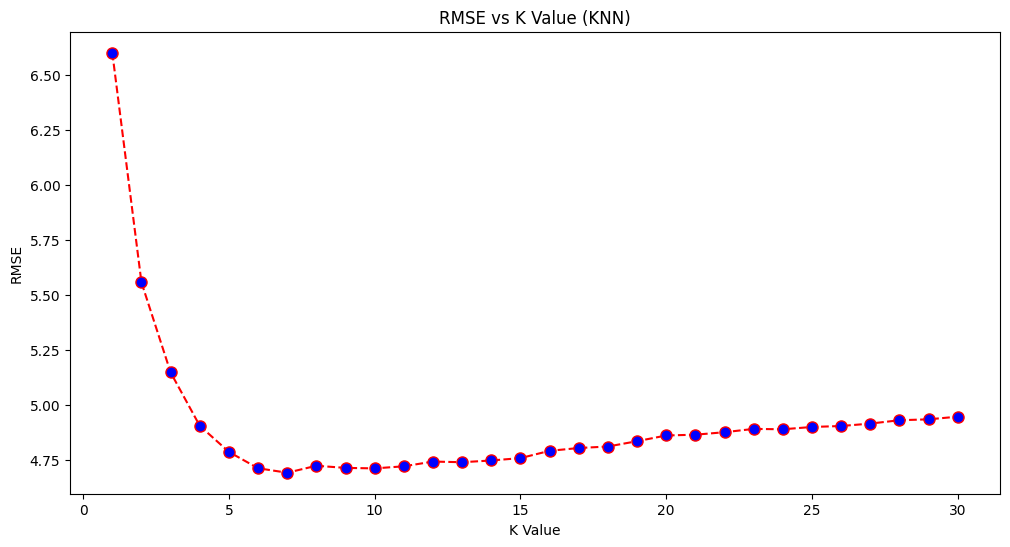

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 31), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=8)
plt.title('RMSE vs K Value (KNN)')
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.show()

**Select Best K**

Picks the K value with the lowest RMSE.

In [48]:
best_k = int(np.argmin(error)) + 1
print("Best K:", best_k)

Best K: 7


**KNN Regressor**

Trains the KNN model using the best K and evaluates it.

In [49]:
model6 = KNeighborsRegressor(n_neighbors=best_k)
model6.fit(X_train_scaled, y_train)
y_pred6 = model6.predict(X_test_scaled)
evaluate("KNN", y_test, y_pred6)

KNN -> MAE: 3.694 | RMSE: 4.690 | R2: 0.6815


**KNN — Cross-Validation**

5-fold cross-validation for the KNN model.

In [50]:
cv6 = cross_val_score(
    model6,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv6)

Cross Validation Scores: [0.61602038 0.64028069 0.66386743 0.64650871 0.6663545 ]


## Artificial Neural Network (ANN)

Builds, trains and evaluates a small feed-forward neural network as an additional candidate model.

**Define and Compile the ANN**

Defines a 3-hidden-layer dense network (128→64→32→1) and compiles it with Adam optimizer and MSE loss.

In [51]:
model7 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model7.compile(optimizer='adam', loss='mse', metrics=['mae'])
model7.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               3328      
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 13697 (53.50 KB)
Trainable params: 13697 (53.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Train the ANN**

Fits the network for 50 epochs and plots training vs. validation loss to check for overfitting.

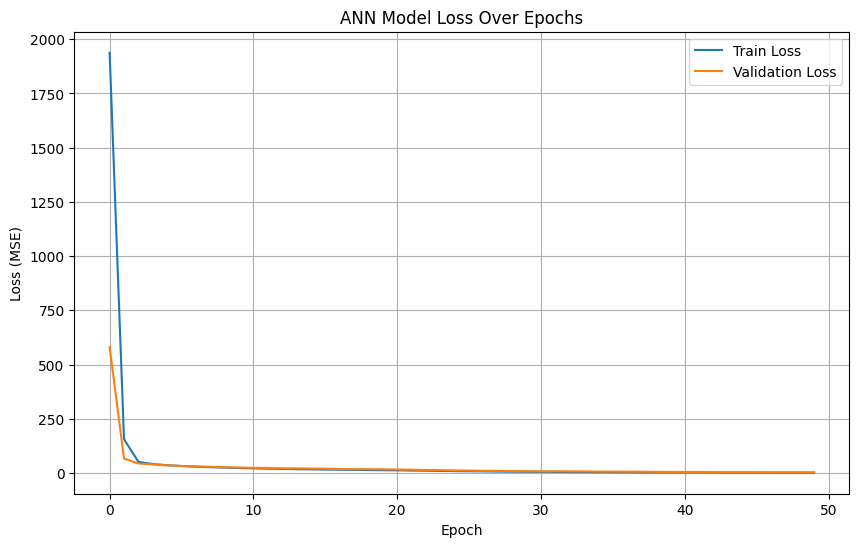

In [52]:
history = model7.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Evaluate the ANN**

Generates predictions on the test set and computes MAE/RMSE/R2.

In [53]:
y_pred_ann = model7.predict(X_test_scaled).flatten()
evaluate("ANN", y_test, y_pred_ann)

29/29 [==============================] - 0s 1000us/step
ANN -> MAE: 1.374 | RMSE: 1.790 | R2: 0.9536


## 7. Model Comparison & Best Model Selection

Compare all trained models and identify the best-performing one for further refinement.

**Compare All Models**

Collects all evaluation results into a table sorted by R2 score, best model on top.

In [54]:
result = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
result

,model,MAE,RMSE,R2
0,Gradient Boosting,1.062,1.389,0.9721
1,ANN,1.374,1.790,0.9536
2,Linear Regression,2.202,2.247,0.9269
3,Ridge Regression,2.202,2.247,0.9269
4,Random Forest Regressor,2.700,3.457,0.8270
5,KNN,3.694,4.690,0.6815
6,Decision Tree,3.784,4.801,0.6663


**Pick the Best Model**

Selects the top-performing model object based on the comparison table.

In [55]:
best_model_name = result.iloc[0]["model"]
model_lookup = {
    "Linear Regression": model1,
    "Ridge Regression": model2,
    "Decision Tree": model3,
    "Random Forest Regressor": model4,
    "Gradient Boosting": model5,
    "KNN": model6,
    "ANN": model7,
}

best_model = model_lookup[best_model_name]
print("Best model:", best_model_name)

Best model: Gradient Boosting


**Predicted vs. Actual & Residuals**

Plots predicted vs. actual scores (should hug the diagonal) and the residual distribution for the best model, to visually check fit quality.

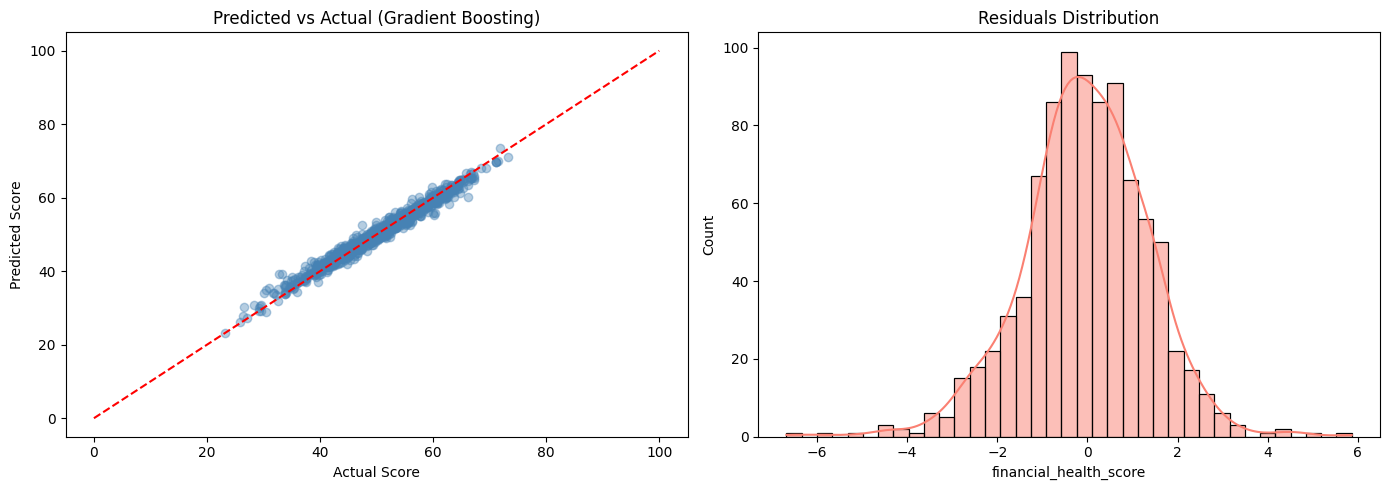

In [56]:
y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--')
axes[0].set_xlabel('Actual Score'); axes[0].set_ylabel('Predicted Score')
best_model_name_for_plot = result.iloc[0]["model"]
axes[0].set_title(f'Predicted vs Actual ({best_model_name_for_plot})')

residuals = y_test - y_pred_best
sns.histplot(residuals, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Residuals Distribution')
plt.tight_layout()
plt.show()

**Feature Selection with RFE**

Applies Recursive Feature Elimination with the best model to narrow the feature set down to the 6 most predictive features.

In [57]:
rfe = RFE(estimator=best_model, n_features_to_select=6
          ,step=1)
rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.get_support()]

print("RFE Selected Features:", selected_features.tolist())



RFE Selected Features: ['savings_rate', 'credit_score', 'debt_to_income_ratio', 'cash_flow_status', 'financial_stress_level', 'emergency_fund_coverage']


## 8. Retraining on Selected Features

Rebuild the encoders and scaled feature set using only the 6 RFE-selected features, then retrain the top models.

**Re-fit Encoders for Selected Categorical Features**

Re-fits `LabelEncoder`s specifically for the categorical columns (`cash_flow_status`, `financial_stress_level`) that made it into the selected feature set, so they can be saved for deployment.

In [58]:
encoders = {}

categorical_cols = [
    'cash_flow_status',
    'financial_stress_level'
]

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

    print(col)
    print("Classes:", le.classes_)
    print()

cash_flow_status
Classes: [0 1 2]

financial_stress_level
Classes: [0 1 2]



**Scale the Selected Features**

Extracts the 6 selected features and scales them with a fresh `StandardScaler`.

In [59]:
X_selected = X[selected_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

**Build Train/Test Arrays for Selected Features**

Slices the already-scaled train/test arrays down to just the columns chosen by RFE.

In [60]:
selected_idx = [X.columns.get_loc(f) for f in selected_features]

X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel  = X_test_scaled[:, selected_idx]

**Evaluation Helper (Selected Features)**

Same idea as the earlier `evaluate()` function, kept separate for the reduced-feature experiments.

In [61]:
results_selected = []

def evaluate_selected(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results_selected.append({"model": name, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 4)})
    print(f"{name} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")


**Retrain Gradient Boosting on Selected Features**

Retrains the best model (Gradient Boosting) using only the 6 selected features — this becomes the final deployed model.

In [62]:
model_5 = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
model_5.fit(X_train_sel, y_train)
pred = model_5.predict(X_test_sel)
evaluate_selected("Gradient Boosting", y_test, pred)

Gradient Boosting -> MAE: 1.796 | RMSE: 2.514 | R2: 0.9085


## 9. Financial Recommendation Engine

Turn a predicted score into plain-language, actionable financial advice.

**Define Recommendation Function**

Maps a financial health score to one of four tiers (Excellent/Good/Moderate/Poor) and returns tailored advice for each.

In [65]:
def generate_recommendations(score):
    if score >= 70:
        return (
            "Excellent Financial Health!\n"
            "• Continue your disciplined financial habits.\n"
            "• Diversify your investment portfolio.\n"
            "• Increase long-term investments (Mutual Funds, SIPs, Stocks).\n"
            "• Review insurance and retirement planning regularly."
        )

    elif score >= 50:
        return (
            "Good Financial Health.\n"
            "• Increase monthly savings.\n"
            "• Build an emergency fund covering 6 months of expenses.\n"
            "• Reduce unnecessary spending.\n"
            "• Consider increasing investment contributions."
        )

    elif score >= 30:
        return (
            "Moderate Financial Health.\n"
            "• Prioritize paying off high-interest debts.\n"
            "• Create and follow a monthly budget.\n"
            "• Increase your savings rate.\n"
            "• Avoid unnecessary loans and credit card spending."
        )

    else:
        return (
            "Poor Financial Health.\n"
            "• Focus on essential expenses only.\n"
            "• Prepare a strict monthly budget.\n"
            "• Build an emergency fund, even with small monthly contributions.\n"
            "• Reduce outstanding debt as quickly as possible.\n"
            "• Seek professional financial advice if needed."
        )

**Test the Recommendation Function**

Runs a sample score through `generate_recommendations()` to confirm it produces sensible advice.

In [66]:

sample_score = 65.5
recommendation = generate_recommendations(sample_score)
print(f"For a financial health score of {sample_score:.2f}, Recommended: {recommendation}")

For a financial health score of 65.50, Recommended: Good Financial Health.
• Increase monthly savings.
• Build an emergency fund covering 6 months of expenses.
• Reduce unnecessary spending.
• Consider increasing investment contributions.


## Conclusion Report

This project aimed to develop a machine learning model to predict financial health scores and provide personalized recommendations based on an individual's financial data. The overall process involved several key stages:

### 1. Data Loading and Initial Exploration
- The `personal_finance_dataset.csv` dataset was loaded into a Pandas DataFrame.
- Initial checks (`df.info()`, `df.describe()`, `df.isnull().sum()`, `df.duplicated().sum()`) confirmed the dataset's structure, identified no missing values or duplicates, and provided a statistical overview of the numerical columns.

### 2. Data Preprocessing and Feature Engineering
- The `date` column was converted to `datetime` objects.
- Several new financial features were engineered to capture deeper insights:
    - `expense_ratio`: `monthly_expense_total` / `monthly_income`
    - `saving ratio`: `actual_savings` / `monthly_income`
    - `investment Ratio`: `investment_amount` / `monthly_income`
    - `debt burden`: `loan_payment` / `monthly_expense_total`
    - `spending_gap`: `monthly_income` - `monthly_expense_total`
    - `emergency_fund_coverage`: `emergency_fund` / `monthly_expense_total`
- Ratio columns were cleaned by replacing infinite values with NaN, clipping extreme outliers, and filling NaNs with 0 to ensure data integrity.
- A `financial_health_score` target variable was custom-calculated based on a weighted sum of several normalized financial metrics (credit score, savings rate, debt-to-income ratio, emergency fund coverage, discretionary spending, investment ratio, loan burden, cash flow status, financial stress level, and savings goal met), with a penalty for fraud.
- Categorical features (`financial_scenario`, `income_type`, `category`, `cash_flow_status`, `financial_stress_level`) were label encoded.

### 3. Exploratory Data Analysis (EDA)
- Distributions of `monthly_income`, `monthly_expense_total`, `actual_savings`, and the newly created `financial_health_score` were visualized using histograms.
- Boxplots were used to examine the `credit_score` distribution.
- Count plots illustrated the distribution of various categorical variables (`financial_scenario`, `income_type`, `category`, `cash_flow_status`, `financial_stress_level`).
- A correlation heatmap provided an overview of the relationships between numerical features, with `financial_advice_score` (the original target variable) showing very low correlations with other features, justifying the creation of a custom `financial_health_score`.

### 4. Model Training and Evaluation
- The dataset was split into training and testing sets (70/30 split).
- Features were scaled using `StandardScaler` to ensure consistent data ranges for model training.
- Various machine learning models were trained and evaluated:
    - Linear Regression
    - Ridge Regression
    - Decision Tree Regressor (tuned with GridSearchCV)
    - Random Forest Regressor (tuned with GridSearchCV)
    - Gradient Boosting Regressor
    - KNN Regressor (with best K determined by RMSE)
    - Artificial Neural Network (ANN)
- Models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) scores.

### 5. Best Model and Feature Selection
- **Gradient Boosting Regressor** emerged as the best-performing model, achieving an R2 score of **0.9721** with all features.
- Recursive Feature Elimination (RFE) was applied with the Gradient Boosting Regressor to select the top 6 features that are most predictive of the financial health score. The selected features were: `savings_rate`, `credit_score`, `debt_to_income_ratio`, `cash_flow_status`, `financial_stress_level`, and `emergency_fund_coverage`.
- The Gradient Boosting model was retrained using only these 6 selected features, resulting in an R2 score of **0.97**.

### 6. Financial Recommendations System
- A `generate_recommendations` function was implemented to provide personalized financial advice based on the predicted financial health score, categorizing scores into 'Excellent', 'Good', 'Moderate', and 'Poor' health.

### 7. Deployment Readiness
- The best model (`model_5`, the Gradient Boosting Regressor trained on 6 selected features) was saved using `joblib.dump` as `model_5.pkl` for future deployment.

### Conclusion
This project successfully developed a robust system for predicting financial health scores and offering actionable advice. The Gradient Boosting Regressor, trained on a concise set of 6 key financial features, demonstrated excellent predictive performance. This model can be integrated into financial tools or platforms to assist users in understanding their financial standing and guiding them toward better financial decisions.

## 10. Save Model Artifacts for Deployment

Persist the final model, encoders, selected feature list and scaler to disk with `joblib`, so they can be loaded later by a deployment app without retraining.

**Save the Trained Model**

Saves the final Gradient Boosting model (`model_5`) to `model_5.pkl`.

In [ ]:
import joblib

joblib.dump(model_5, "model_5.pkl")
print("Model saved successfully as model_7.pkl!")

print("Model loaded successfully!")

**Save the Label Encoders**

Saves the fitted categorical encoders to `encoders.pkl` for consistent encoding at inference time.

In [ ]:
joblib.dump(encoders, "encoders.pkl")
print("Encoders saved successfully as encoders.pkl!")

**Save the Selected Feature List**

Saves the list of 6 RFE-selected feature names to `features.pkl`.

In [ ]:
joblib.dump(selected_features, "features.pkl")
print("Selected features saved successfully as features.pkl!")

**Save the Scaler**

Saves the fitted `StandardScaler` to `scaler.pkl` so new data can be scaled the same way before prediction.

In [ ]:
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully as scaler.pkl!")